In [3]:
using Plots
using Serialization

x, y, a1_all, a2_all, d_all, H_all =
            deserialize("../../../../examples/fracture/elastic/2d/runs/sol_gammastar_m1_lambda_121.15_mu_80.77_C3_0.37*1e3_Nx40_Ny40_l0.075_ID_notch_f1right_0.01_steps_500_simple_d_false.jls")

print(length(a1_all[1,1,:]))

501

In [4]:
anim = @animate for iter in 1:length(a1_all[1,1,:])

    # transpose
    a1p = a1_all[:,:,iter]'
    a2p = a2_all[:,:,iter]'
    dp = d_all[:,:,iter]'

    Nx = length(x)
    Ny = length(y)

    # coordinate matrices
    X = [xi for yi in y, xi in x]
    Y = [yi for yi in y, xi in x]

    # deformed coordinates
    Xd = X .+ a1p
    Yd = Y .+ a2p

    plt = plot(
        aspect_ratio = 1,
        xlabel = "x",
        ylabel = "y",
        legend = false,
        title = "Elastic Square"
    )

    # node heatmap
    scatter!(
        plt,
        vec(Xd),
        vec(Yd),
        marker = :square,
        marker_z = vec(dp),
        ms = 6,
        color = :coolwarm,
        markerstrokewidth = 0,   # removes black circle border
        colorbar = true,
        clim=(0,1)
    )

    # grid lines
    for i in 1:Ny
        plot!(plt, Xd[i,:], Yd[i,:], color=:black, lw=1)
    end

    for j in 1:Nx
        plot!(plt, Xd[:,j], Yd[:,j], color=:black, lw=1)
    end

        # --- add red boundary lines for original shape---

    # bottom and top
    plot!(X[1, :],    Y[1, :],    color=:red, lw=1.5)
    plot!(X[end, :],  Y[end, :],  color=:red, lw=1.5)

    # left and right
    plot!(X[:, 1],    Y[:, 1],    color=:red, lw=1.5)
    plot!(X[:, end],  Y[:, end],  color=:red, lw=1.5)

    #plt
    #display(plt)
end

#gif(anim, "./elastic_square.gif", fps = 20)

Animation("/tmp/jl_SYvZiT", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000492.png", "000493.png", "000494.png", "000495.png", "000496.png", "000497.png", "000498.png", "000499.png", "000500.png", "000501.png"])

In [5]:
mp4(anim, "sol_gammastar_m1_lambda_121.15_mu_80.77_C3_0.37*1e3_Nx40_Ny40_l0.075_ID_notch_f1right_0.01_steps_500_simple_d_false.mp4", fps = 10)


[ Info: Saved animation to /home/tgia02/repos/ice_modelling/notebooks/fracture/elastic/2d/sol_gammastar_m1_lambda_121.15_mu_80.77_C3_0.37*1e3_Nx40_Ny40_l0.075_ID_notch_f1right_0.01_steps_500_simple_d_false.mp4


Plots.AnimatedGif("/home/tgia02/repos/ice_modelling/notebooks/fracture/elastic/2d/sol_gammastar_m1_lambda_121.15_mu_80.77_C3_0.37*1e3_Nx40_Ny40_l0.075_ID_notch_f1right_0.01_steps_500_simple_d_false.mp4")

In [80]:
t[230]

0.458

In [30]:
a2[1,:]

40-element Vector{Float64}:
 -5.167037577124284e-16
  2.4289216665239547e-14
  1.2660911832158195e-14
 -8.726593750246758e-16
 -2.557826034915282e-15
 -6.209410384093274e-15
  4.116968486815194e-15
 -6.902757261142119e-15
  1.963222337260523e-15
  1.0457889544920299e-14
  ⋮
  1.8247709903473257e-15
 -1.0818954019293972e-14
  3.7936156740209324e-15
  2.7487322417607174e-15
  6.774794201436116e-15
 -1.7892559715491818e-15
  8.216469878352e-16
  1.6383716328496602e-15
 -8.317964768915263e-16

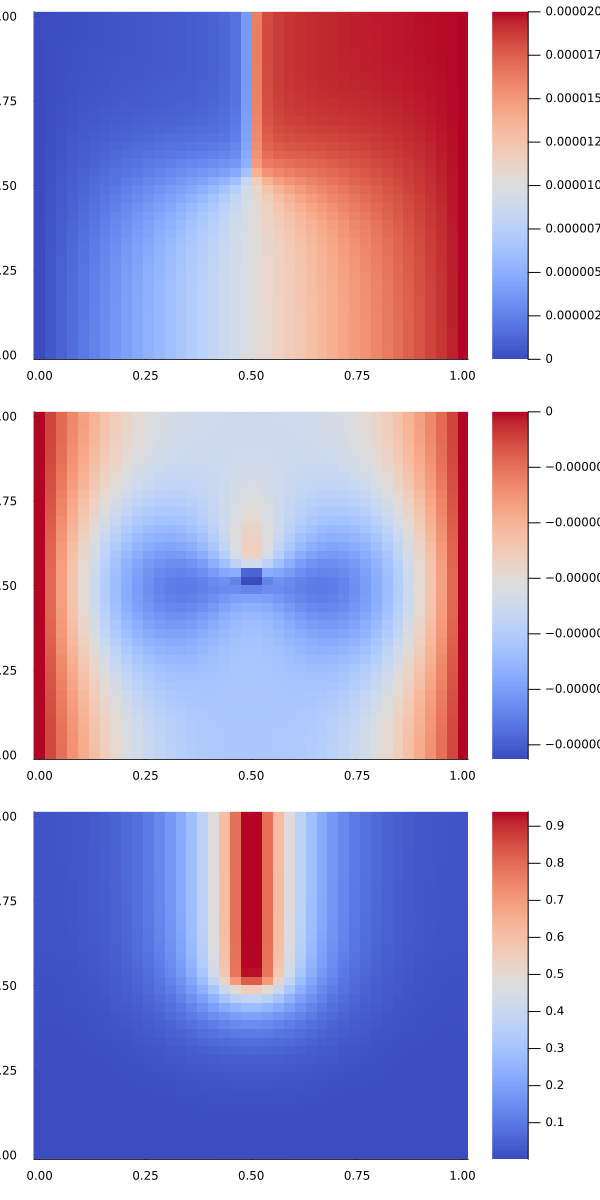

In [4]:
ii = 2
a1 = a1_all[:,:,ii]
a2 = a2_all[:,:,ii]
d = d_all[:,:,ii]

p1 = heatmap(x, y, a1', color = :coolwarm,)
p2 = heatmap(x, y, a2', color = :coolwarm,)
p3 = heatmap(x, y, d', color = :coolwarm,)

plot(p1,p2,p3, layout=(3,1), size=(600,1200))

In [75]:
function Dx(x,f)
    Nx = length(x)
    Δx = x[2]-x[1]
    fx = 0.0*copy(f)
    fx[1,:] .= (f[2,:] .- f[1,:]) / Δx # (- 0.5*f[3,:] .+ 2*f[2,:] .- 1.5*f[1,:]) / Δx 
    fx[Nx,:] .= (f[Nx,:] .- f[Nx-1,:]) / Δx
    for i in 2:Nx-1
        fx[i,:] .= (f[i+1,:] .- f[i-1,:]) / (2Δx)
    end
    return fx
end

function Dy(y,f)
    Ny = length(y)
    Δy = y[2]-y[1]
    fy = 0.0*copy(f)
    fy[:,1] .= (f[:,2] .- f[:,1]) / Δy
    fy[:,Ny] .=  (f[:,Ny] .- f[:,Ny-1]) / Δy
    for j in 2:Ny-1
        fy[:,j] .= (f[:,j+1] .- f[:,j-1]) / (2Δy)
    end
    return fy
end

Dy (generic function with 1 method)

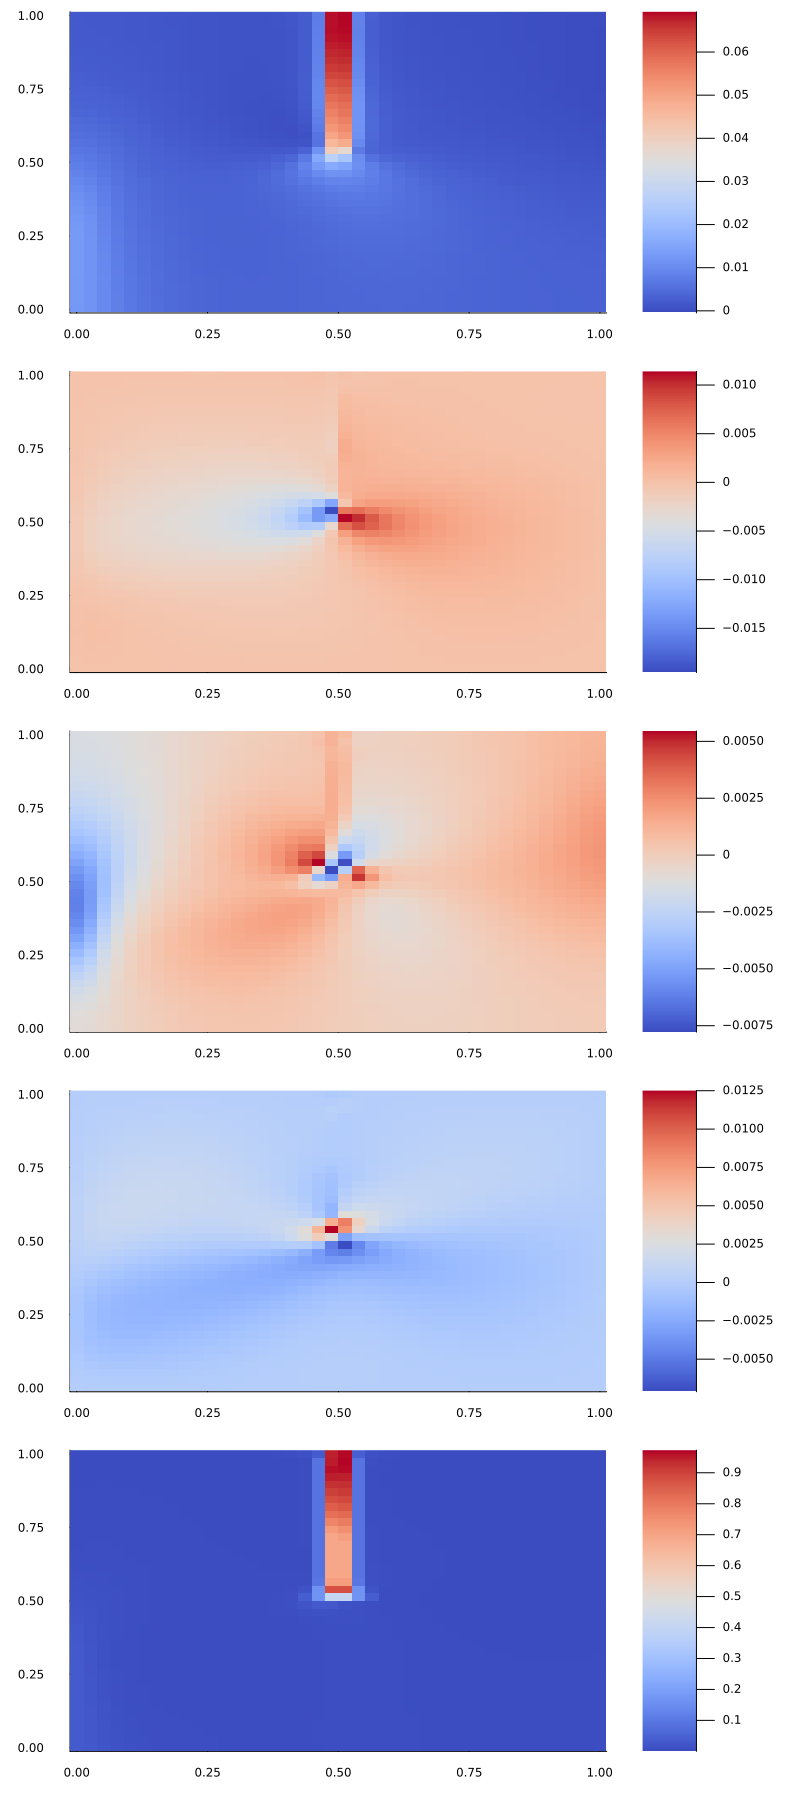

In [53]:
ii = 230

a1 = a1_all[:,:,ii]
a1x = Dx(x,a1)
a1y = Dy(y,a1)

a2 = a2_all[:,:,ii]
a2x = Dx(x,a2)
a2y = Dy(y,a2)

H = H_all[:,:,ii]

p1 = heatmap(x, y, a1x', color = :coolwarm,)
p2 = heatmap(x, y, a1y', color = :coolwarm,)
p3 = heatmap(x, y, a2x', color = :coolwarm,)
p4 = heatmap(x, y, a2y', color = :coolwarm,)
p5 = heatmap(x, y, H', color = :coolwarm,)

plot(p1,p2,p3,p4,p5, layout=(5,1), size=(800,1800),
     left_margin = 10Plots.mm)

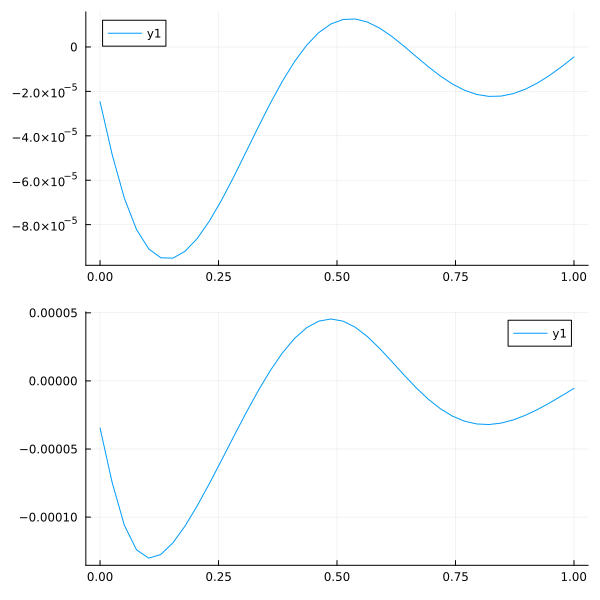

In [54]:
p1 = plot(x,a2[:,1])
p2 = plot(x,a2y[:,1])

plot(p1,p2, layout=(2,1), size=(600,600))

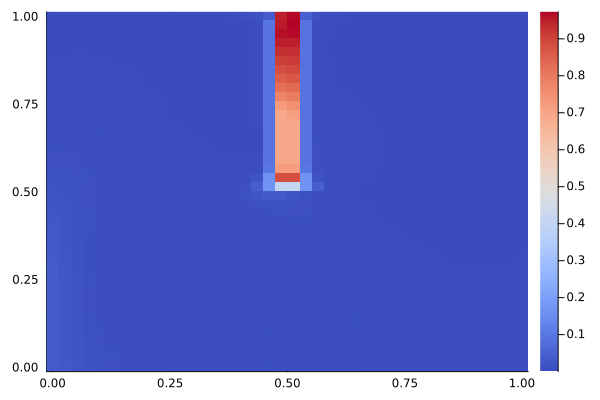

In [56]:
heatmap(x, y, H_all[:,:,ii]', color = :coolwarm)

In [57]:
# use the fact that the ghost point copies the value of the last point in the grid, in the y direction
function Dy_ghost(f,i,j,y)
    Ny = length(y)
    Δy = y[2]-y[1]
    if j == 1
        return (f[i,j+1] - f[i,j]) / (2*Δy) # assumes f[i,j-1] = f[i,j]
    elseif j == Ny
        return (f[i,j] - f[i,j-1]) / (2*Δy) # assumes f[i,j+1] = f[i,j]
    else
        return (f[i,j+1] - f[i,j-1]) / (2*Δy)
    end
end

# use prescribed Dirichlet BC
function Dx_ghost(f,i,j,x, f_left, f_right)
    Nx = length(x)
    Δx = x[2]-x[1]
    if i == 1
        return (f[i+1,j] - f_left[j]) / (2*Δx)
    elseif i == Nx
        return (f_right[j] - f[i-1,j]) / (2*Δx)
    else
        return (f[i+1,j] - f[i-1,j]) / (2*Δx)
    end
end



Dx_ghost (generic function with 1 method)

In [58]:
Ny = length(y)
Nx = length(x)

T = 501
t = range(0.0,1,T)

f1_left  = -0*1e-1*ones(Ny)
f1_right =  t[ii] * 1e-2*ones(Ny);

In [59]:
a1_x_ghost = zeros(Nx,Ny)
a2_y_ghost = zeros(Nx,Ny)

for j in 1:Ny
    for i in 1:Nx
        a1_x_ghost[i,j] = Dx_ghost(a1,i,j,x,f1_left,f1_right) 
        a2_y_ghost[i,j] = Dy_ghost(a2,i,j,y)
    end
end

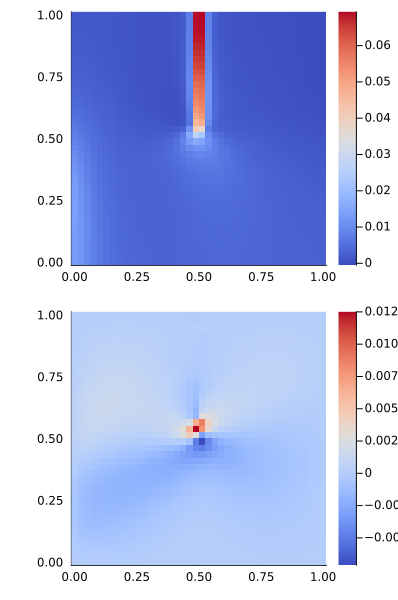

In [60]:
p1 = heatmap(x, y, a1_x_ghost', color = :coolwarm,)
p2 = heatmap(x, y, a2_y_ghost', color = :coolwarm,)

plot(p1,p2, layout=(2,1), size=(400,600),
     left_margin = 10Plots.mm)